In [1]:
import numpy as np
from scipy.optimize import minimize, LinearConstraint
from scipy import integrate
from scipy.sparse import csc_matrix
import time
import matplotlib.pyplot as plt
import pandas as pd
from numba import jit, njit
from matplotlib.ticker import LogLocator

#plt.style.use('/Users/koichiro/Dropbox/GraduateResearch/quantumSensor/physrev.mplstyle')
#plt.style.use('/Users/koichiromacmini/Dropbox/GraduateResearch/quantumSensor/physrev.mplstyle')
plt.style.use('/Users/koichiromacstudio/Dropbox/GraduateResearch/quantumSensor/physrev.mplstyle')

In [19]:
kg = 5.62e35
sec = 1.51976e15
yr = np.pi * 1e7 * sec
eV = 1

scalingTES = 1e22 / 3.17e-8

TES10MeV01eV_norm = kg/1e22/1/.83 * scalingTES
TES10MeV1eV_norm = kg/1e22/1/2.3 * scalingTES

TES1000MeV01eV_norm = kg/(1e22)/3.83 * scalingTES
TES1000MeV1eV_norm = kg/(1e22)/3.92/0.818 * scalingTES

scalingMKID = 1e21 / 3.17e-8

MKID10MeV02eV_norm = kg/1e22/.095/1.02/.997 * scalingMKID
MKID10MeV1eV_norm = kg/1e22/.92/.43/.99/.98/.997 * scalingMKID

MKID1000MeV02eV_norm = kg/1e22/.145/1.06 * scalingMKID
MKID1000MeV1eV_norm = kg/1e22/.234/1.04 * scalingMKID

<Figure size 800x600 with 0 Axes>

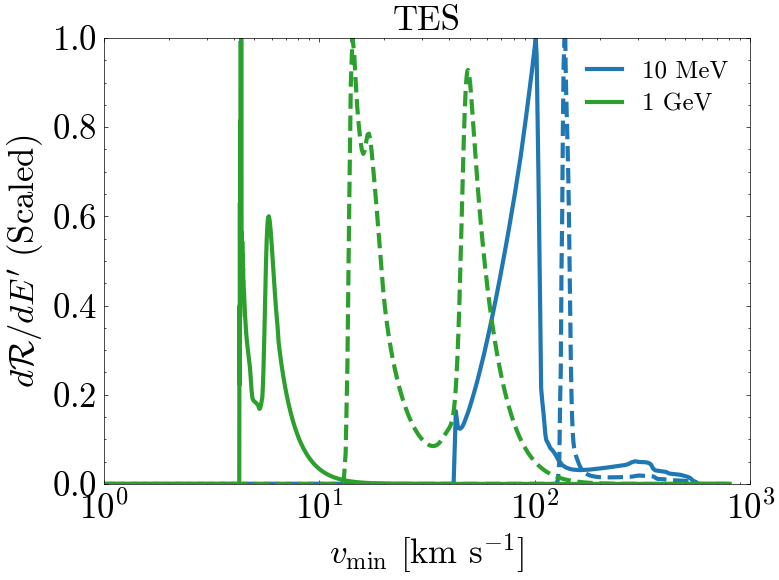

In [41]:
plt.figure(figsize=(8, 6))
plt.rcParams['ytick.labelsize'] = 20
plt.rcParams['xtick.labelsize'] = 20

# CSV を読む
pts1 = np.loadtxt("dcurlyRdomegaP_10MeV_1e-1eV.csv", delimiter=",")
pts2 = np.loadtxt("dcurlyRdomegaP_10MeV_1eV.csv", delimiter=",")


# 1列目が x = vmin, 2列目が y
x1 = pts1[:, 0]
y1 = pts1[:, 1]

x2 = pts2[:, 0]
y2 = pts2[:, 1]


# プロット
plt.figure(figsize=(8, 6))
plt.plot(x1, y1, linewidth=3, color = 'tab:blue', label = '10 MeV', ls = 'solid')
plt.plot(x2, y2, linewidth=3, color = 'tab:blue', ls = 'dashed')

# CSV を読む
pts1 = np.loadtxt("dcurlyRdomegaP_1000MeV_1e-1eV.csv", delimiter=",")
pts2 = np.loadtxt("dcurlyRdomegaP_1000MeV_1eV.csv", delimiter=",")


# 1列目が x = vmin, 2列目が y
x1 = pts1[:, 0]
y1 = pts1[:, 1]

x2 = pts2[:, 0]
y2 = pts2[:, 1]


plt.plot(x1, y1, linewidth=3, color = 'tab:green', label = '1 GeV', ls = 'solid')
plt.plot(x2, y2, linewidth=3, color = 'tab:green', ls = 'dashed')

plt.gca().xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(1.0, 10) * 0.1, numticks=20))

plt.tick_params(axis='both', which='major', labelsize=25)
plt.tick_params(axis='both', which='minor', labelsize=25)
plt.xlabel(r"$v_{\min}$ [km s$^{-1}$]", fontsize = 25)
plt.ylabel(r"$d\mathcal{R}/dE^\prime\ \mathrm{(Scaled)}$", fontsize = 25)
plt.title("TES", fontsize = 25)
#plt.grid(True, which="both", ls="--")
plt.xscale('log')
plt.legend(loc = 'upper right', fontsize = 18, frameon = False)

#plt.grid(True, which="both", ls="--")
plt.ylim(0, 1)
plt.xlim(1, 1000)
plt.tight_layout()
plt.savefig('differentialCurlyR_TES_q=0_scaled.pdf')

<Figure size 800x600 with 0 Axes>

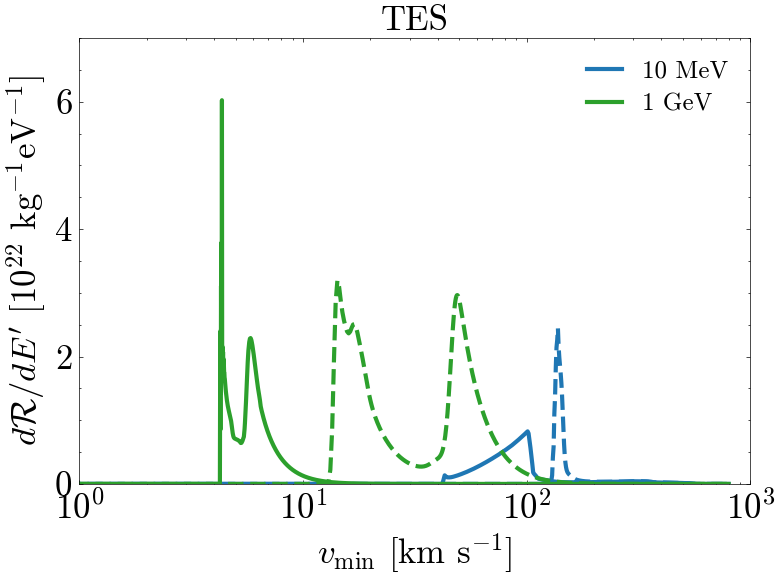

In [40]:
plt.figure(figsize=(8, 6))
plt.rcParams['ytick.labelsize'] = 20
plt.rcParams['xtick.labelsize'] = 20

# CSV を読む
pts1 = np.loadtxt("dcurlyRdomegaP_10MeV_1e-1eV.csv", delimiter=",")
pts2 = np.loadtxt("dcurlyRdomegaP_10MeV_1eV.csv", delimiter=",")


# 1列目が x = vmin, 2列目が y
x1 = pts1[:, 0]
y1 = pts1[:, 1]

x2 = pts2[:, 0]
y2 = pts2[:, 1]


# プロット
plt.figure(figsize=(8, 6))
plt.plot(x1, y1/TES10MeV01eV_norm / (sec/kg/yr/eV), linewidth=3, color = 'tab:blue', label = '10 MeV', ls = 'solid')
plt.plot(x2, y2/TES10MeV1eV_norm / (sec/kg/yr/eV), linewidth=3, color = 'tab:blue', ls = 'dashed')

# CSV を読む
pts1 = np.loadtxt("dcurlyRdomegaP_1000MeV_1e-1eV.csv", delimiter=",")
pts2 = np.loadtxt("dcurlyRdomegaP_1000MeV_1eV.csv", delimiter=",")


# 1列目が x = vmin, 2列目が y
x1 = pts1[:, 0]
y1 = pts1[:, 1]

x2 = pts2[:, 0]
y2 = pts2[:, 1]


plt.plot(x1, y1/TES1000MeV01eV_norm / (sec/kg/yr/eV), linewidth=3, color = 'tab:green', label = '1 GeV', ls = 'solid')
plt.plot(x2, y2/TES1000MeV1eV_norm / (sec/kg/yr/eV), linewidth=3, color = 'tab:green', ls = 'dashed')

plt.gca().xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(1.0, 10) * 0.1, numticks=20))

plt.tick_params(axis='both', which='major', labelsize=25)
plt.tick_params(axis='both', which='minor', labelsize=25)
plt.xlabel(r"$v_{\min}$ [km s$^{-1}$]", fontsize = 25)
plt.ylabel(r"$d\mathcal{R}/dE^\prime$ [$10^{22}$ kg$^{-1}$eV$^{-1}$]", fontsize = 25)
plt.title("TES", fontsize = 25)
#plt.grid(True, which="both", ls="--")
plt.xscale('log')
plt.legend(loc = 'upper right', fontsize = 18, frameon = False)

#plt.grid(True, which="both", ls="--")
plt.ylim(0, 7)
#plt.yscale('log')
plt.xlim(1, 1000)
plt.tight_layout()
plt.savefig('differentialCurlyR_TES_q=0.pdf')

<Figure size 800x600 with 0 Axes>

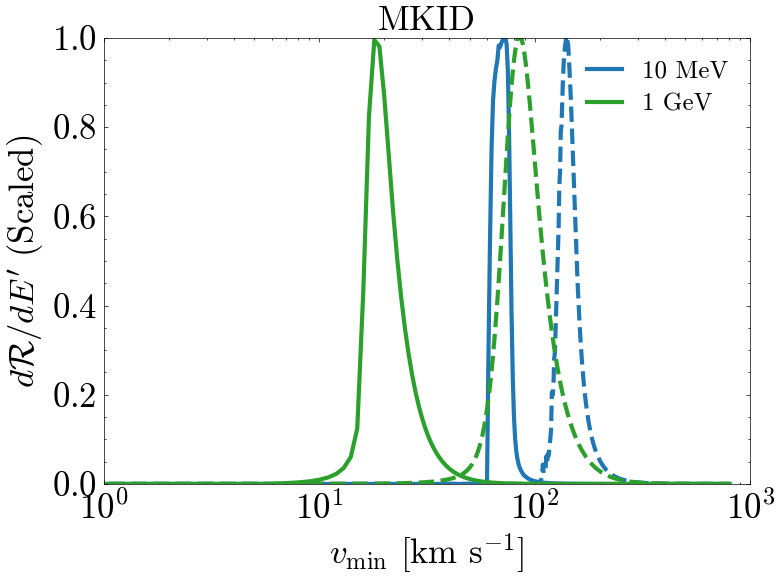

In [39]:
plt.figure(figsize=(8, 6))
plt.rcParams['ytick.labelsize'] = 20
plt.rcParams['xtick.labelsize'] = 20

# CSV を読む
pts1 = np.loadtxt("dcurlyRdomegaP_10MeV_2e-1eV_TiN.csv", delimiter=",")
pts2 = np.loadtxt("dcurlyRdomegaP_10MeV_1eV_TiN.csv", delimiter=",")


# 1列目が x = vmin, 2列目が y
x1 = pts1[:, 0]
y1 = pts1[:, 1]

x2 = pts2[:, 0]
y2 = pts2[:, 1]


# プロット
plt.figure(figsize=(8, 6))
plt.plot(x1, y1, linewidth=3, color = 'tab:blue', label = '10 MeV', ls = 'solid')
plt.plot(x2, y2, linewidth=3, color = 'tab:blue', ls = 'dashed')

# CSV を読む
pts1 = np.loadtxt("dcurlyRdomegaP_1000MeV_2e-1eV_TiN.csv", delimiter=",")
pts2 = np.loadtxt("dcurlyRdomegaP_1000MeV_1eV_TiN.csv", delimiter=",")


# 1列目が x = vmin, 2列目が y
x1 = pts1[:, 0]
y1 = pts1[:, 1]

x2 = pts2[:, 0]
y2 = pts2[:, 1]


plt.plot(x1, y1, linewidth=3, color = 'tab:green', label = '1 GeV', ls = 'solid')
plt.plot(x2, y2, linewidth=3, color = 'tab:green', ls = 'dashed')

plt.gca().xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(1.0, 10) * 0.1, numticks=20))

plt.tick_params(axis='both', which='major', labelsize=25)
plt.tick_params(axis='both', which='minor', labelsize=25)
plt.xlabel(r"$v_{\min}$ [km s$^{-1}$]", fontsize = 25)
plt.ylabel(r"$d\mathcal{R}/dE^\prime\ \mathrm{(Scaled)}$", fontsize = 25)
plt.title("MKID", fontsize = 25)
#plt.grid(True, which="both", ls="--")
plt.xscale('log')
plt.legend(loc = 'upper right', fontsize = 18, frameon = False)

plt.ylim(0, 1)
plt.xlim(1, 1000)
plt.tight_layout()
plt.savefig('differentialCurlyR_MKID_q=0_scaled.pdf')

<Figure size 800x600 with 0 Axes>

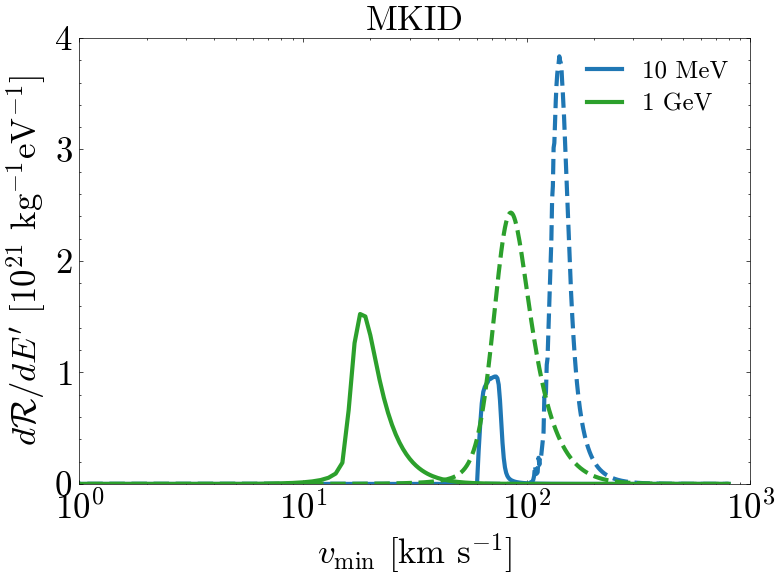

In [38]:
plt.figure(figsize=(8, 6))
plt.rcParams['ytick.labelsize'] = 20
plt.rcParams['xtick.labelsize'] = 20

# CSV を読む
pts1 = np.loadtxt("dcurlyRdomegaP_10MeV_2e-1eV_TiN.csv", delimiter=",")
pts2 = np.loadtxt("dcurlyRdomegaP_10MeV_1eV_TiN.csv", delimiter=",")


# 1列目が x = vmin, 2列目が y
x1 = pts1[:, 0]
y1 = pts1[:, 1]

x2 = pts2[:, 0]
y2 = pts2[:, 1]


# プロット
plt.figure(figsize=(8, 6))
plt.plot(x1, y1/MKID10MeV02eV_norm / (sec/kg/yr/eV), linewidth=3, color = 'tab:blue', label = '10 MeV', ls = 'solid')
plt.plot(x2, y2/MKID10MeV1eV_norm / (sec/kg/yr/eV), linewidth=3, color = 'tab:blue', ls = 'dashed')

# CSV を読む
pts1 = np.loadtxt("dcurlyRdomegaP_1000MeV_2e-1eV_TiN.csv", delimiter=",")
pts2 = np.loadtxt("dcurlyRdomegaP_1000MeV_1eV_TiN.csv", delimiter=",")


# 1列目が x = vmin, 2列目が y
x1 = pts1[:, 0]
y1 = pts1[:, 1]

x2 = pts2[:, 0]
y2 = pts2[:, 1]


plt.plot(x1, y1/MKID1000MeV02eV_norm / (sec/kg/yr/eV), linewidth=3, color = 'tab:green', label = '1 GeV', ls = 'solid')
plt.plot(x2, y2/MKID1000MeV1eV_norm / (sec/kg/yr/eV), linewidth=3, color = 'tab:green', ls = 'dashed')

plt.gca().xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(1.0, 10) * 0.1, numticks=20))

plt.tick_params(axis='both', which='major', labelsize=25)
plt.tick_params(axis='both', which='minor', labelsize=25)
plt.xlabel(r"$v_{\min}$ [km s$^{-1}$]", fontsize = 25)
plt.ylabel(r"$d\mathcal{R}/dE^\prime$ [$10^{21}$ kg$^{-1}$eV$^{-1}$]", fontsize = 25)
plt.title("MKID", fontsize = 25)
#plt.grid(True, which="both", ls="--")
plt.xscale('log')
plt.legend(loc = 'upper right', fontsize = 18, frameon = False)

plt.ylim(0, 4)
#plt.yscale('log')
plt.xlim(1, 1000)
plt.tight_layout()
plt.savefig('differentialCurlyR_MKID_q=0.pdf')